# 📊 Aggregating Phases of Play


## 📋 Prerequisites

- Python installed
- Required libraries: `numpy`, `pandas`, `skillcorner`

```bash
pip install numpy pandas skillcorner
```


## 📋 Step 1: Setup & Prerequisites


In [1]:
import sys
from io import BytesIO
from platform import python_branch

import numpy as np
import pandas as pd
from skillcorner.client import SkillcornerClient

from opendata.features.PhasesOfPlayAggregator import PhasesOfPlayAggregator


## 📥 Step 2: Load Phases of Play Data


In [ ]:
import os

match_id = 1886347

# Instantiate the SkillCorner client
username = os.environ.get("SKILLCORNER_USERNAME")
password = os.environ.get("SKILLCORNER_PASSWORD")
client = SkillcornerClient(username=username, password=password)

# Load dynamic event data from SkillCorner API
# events_df = pd.read_csv(BytesIO(client.get_dynamic_events(MATCH_ID)))

# Load dynamic event data from Open Source
phases_df = pd.read_csv(
    f"../../../data/matches/{match_id}/{match_id}_phases_of_play.csv",
)


## 📊 Step 3: Generate Standard Aggregates


In [3]:
# Initialize the aggregator
phases_aggregator = PhasesOfPlayAggregator(phases_of_play_df=phases_df)

# Off-ball runs
in_possession_aggregates = phases_aggregator.get_in_possession_aggregates()
in_possession_aggregates.rename(
    columns={
        "team_in_possession_id": "team_id",
        "team_in_possession_shortname": "team_name",
    },
    inplace=True,
)
out_of_possession_aggregates = phases_aggregator.get_out_of_possession_aggregates()
out_of_possession_aggregates.rename(
    columns={
        "team_out_of_possession_id": "team_id",
        "team_out_of_possession_shortname": "team_name",
    },
    inplace=True,
)
phases_of_play_aggregates_all = in_possession_aggregates.merge(
    out_of_possession_aggregates,
    on=["match_id", "team_id", "team_name"],
    suffixes=("_ip", "_oop"),
)
phases_of_play_aggregates_all.head()


,match_id,team_id,team_name,count_build_up,total_time_build_up,count_player_possessions_build_up,count_possession_lost_in_phase_build_up,count_possession_lead_to_shot_build_up,count_possession_lead_to_goal_build_up,avg_start_width_build_up,...,count_into_transition_from_defending_set_play,count_into_quick_break_from_defending_set_play,count_into_direct_from_defending_set_play,count_into_chaotic_from_defending_set_play,count_into_low_block_from_defending_set_play,count_into_medium_block_from_defending_set_play,count_into_high_block_from_defending_set_play,count_into_defending_quick_break_from_defending_set_play,count_into_defending_transition_from_defending_set_play,count_into_defending_direct_from_defending_set_play
0,1886347,1805,Newcastle,39.0,353.7,129.0,4.0,3.0,0.0,41.585556,...,NaN,NaN,NaN,2.0,2.0,3.0,NaN,NaN,NaN,NaN
1,1886347,4177,Auckland FC,24.0,219.0,72.0,3.0,3.0,0.0,45.182083,...,NaN,NaN,NaN,1.0,1.0,2.0,NaN,NaN,NaN,NaN


We now have a master dataframe per team per game with all the key aggregates for phases, namely

- Counts (Overall and outcomes)
- Durations


## ⚙️ Step 4: Calculate percentage of time spent


In [4]:
# This gives you the list of available time columns from the aggregates
time_columns = [
    i for i in phases_of_play_aggregates_all.columns.tolist() if "time" in i
]
time_columns


['total_time_build_up',
 'total_time_create',
 'total_time_finish',
 'total_time_transition',
 'total_time_quick_break',
 'total_time_direct',
 'total_time_chaotic_ip',
 'total_time_set_play',
 'total_time_low_block',
 'total_time_medium_block',
 'total_time_high_block',
 'total_time_defending_transition',
 'total_time_defending_quick_break',
 'total_time_defending_direct',
 'total_time_chaotic_oop',
 'total_time_defending_set_play']

In [5]:
phases_of_play_aggregates_duration = phases_of_play_aggregates_all[
    ["match_id", "team_id", "team_name", *time_columns]
]

for time_col in time_columns:
    phases_of_play_aggregates_duration[time_col + "_pct"] = (
        phases_of_play_aggregates_duration[time_col]
        * 100
        / phases_of_play_aggregates_duration[time_columns].sum(axis=1)
    )

phases_of_play_aggregates_duration


/tmp/ipykernel_20946/3889925383.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phases_of_play_aggregates_duration[time_col + "_pct"] = (
/tmp/ipykernel_20946/3889925383.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  phases_of_play_aggregates_duration[time_col + "_pct"] = (
/tmp/ipykernel_20946/3889925383.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

,match_id,team_id,team_name,total_time_build_up,total_time_create,total_time_finish,total_time_transition,total_time_quick_break,total_time_direct,total_time_chaotic_ip,...,total_time_chaotic_ip_pct,total_time_set_play_pct,total_time_low_block_pct,total_time_medium_block_pct,total_time_high_block_pct,total_time_defending_transition_pct,total_time_defending_quick_break_pct,total_time_defending_direct_pct,total_time_chaotic_oop_pct,total_time_defending_set_play_pct
0,1886347,1805,Newcastle,353.7,646.9,150.1,NaN,NaN,36.2,166.7,...,5.245437,1.198867,15.053493,21.576463,6.891126,1.378225,0.704846,1.164254,4.660164,4.779736
1,1886347,4177,Auckland FC,219.0,685.7,478.4,43.8,22.4,37.0,148.1,...,4.660164,4.779736,4.723096,20.355570,11.129641,NaN,NaN,1.139081,5.245437,1.198867


## 🎨 Step 5: Visualization


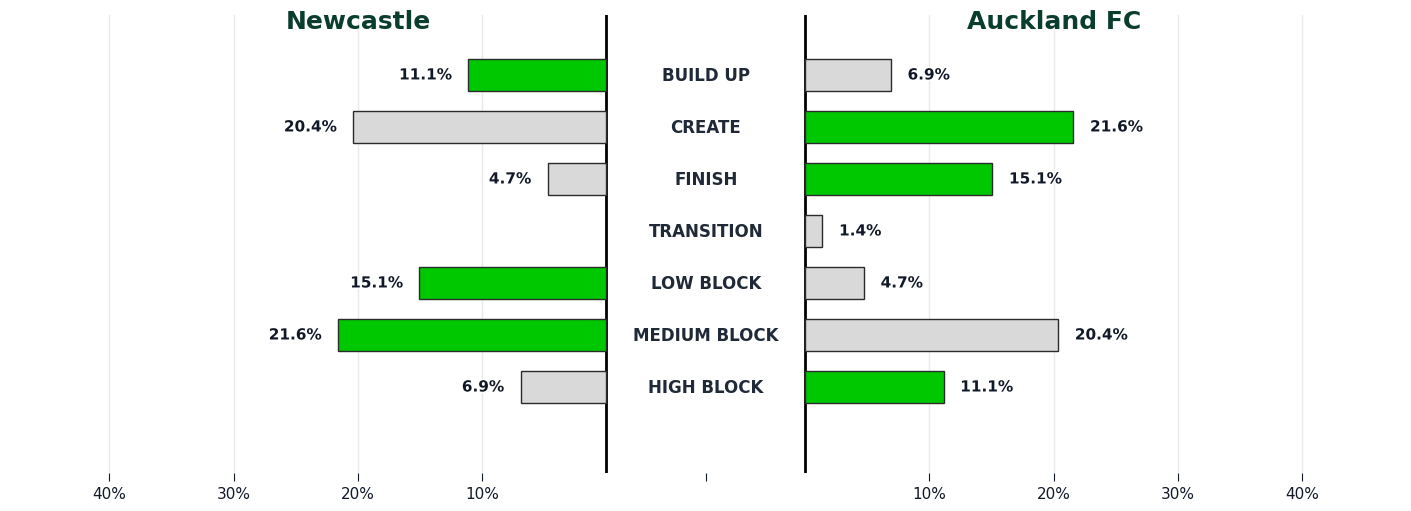

In [6]:
from opendata.visualization.head2head_viz import plot_head2head

metrics_of_interest = {
    "total_time_build_up_pct": "BUILD UP",
    "total_time_create_pct": "CREATE",
    "total_time_finish_pct": "FINISH",
    "total_time_transition_pct": "TRANSITION",
    "total_time_low_block_pct": "LOW BLOCK",
    "total_time_medium_block_pct": "MEDIUM BLOCK",
    "total_time_high_block_pct": "HIGH BLOCK",
}


fig, ax = plot_head2head(
    phases_of_play_aggregates_duration,
    category_column="team_name",
    metrics=metrics_of_interest.keys(),
    metric_labels=metrics_of_interest,
    unit="%",
    xaxis="auto",
)


fig.savefig("test.png", dpi=300, format="png", transparent=False)
